In [1]:
# Evolution of simulations - Twist
# Results for the negative twisted systems can start to be produced after Dec. 6
import MDAnalysis as md
import numpy as np
import matplotlib.pyplot as plt
import twistaly as tw

# Import data
files_dir = "mdresults"
twists = [0.01, 0.02]
utws = [[] for i in range(len(twists))]

for i, tws in enumerate(twists):
    u_filedir = files_dir + f"/tw{tws}"
    utws[i] = md.Universe(u_filedir + "/md_1.tpr", u_filedir + "/md_1_noPBC.xtc")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Atoms To Analyze ---
chains_tws = [[] for i in range(len(twists))]
proteins = [[] for i in range(len(twists))]
atom_gp = "name CA"

for i in range(len(twists)):
    proteins[i] = utws[i].select_atoms("protein")
    chains_tws[i] = proteins[i].fragments

In [3]:
# --- Time Data ---
tf = 100 # ns
time = np.linspace(0, tf, len(utws[0].trajectory))

# --- Protein Data ---
num_mol = int(len(chains_tws[0])/3)

In [4]:
slope = [np.zeros(len(time)) for i in range(len(twists))] # Each of the configurations evolution
threshold = 0.2

for i in range(len(time)):
    # --- SET THE FRAME to the time ---
    for u in utws:
        u.trajectory._read_frame(i) # Move to TimeStep

    # --- Compute Psis ---
    for j, chains in enumerate(chains_tws):
        com = proteins[j].center_of_mass()
        psi_u = np.zeros(num_mol)
        rad_u = np.zeros(num_mol)
        r2_u = np.zeros(num_mol)

        for mol in range(num_mol):
            mol_coords = (chains[3*mol].select_atoms(atom_gp) + chains[3*mol + 1].select_atoms(atom_gp)+ chains[3*mol + 2].select_atoms(atom_gp)).positions - np.array([com[0], com[1], 0.0])
            
            # --- Compute Psi ---
            mol_coords_filt = tw.remove_ends(0.5, mol_coords) / 10
            r, phi, z = tw.cyl_proj(mol_coords_filt)
            arc = r*phi

            tau, _, dr2 = tw.ortreglinfit(z, arc)
            psi_u[mol] = np.rad2deg(np.atan(tau))
            rad_u[mol] = np.mean(r)
            r2_u[mol] = dr2 # Similar to R^2
            
        # --- Filtering and Fit ---
        mask = (r2_u < threshold)
        psi_gr2 = psi_u[mask]
        rad_gr2 = rad_u[mask]

        m, _ = np.polyfit(rad_gr2, psi_gr2, 1)

        # --- Save Slope ---
        slope[j][i] = m

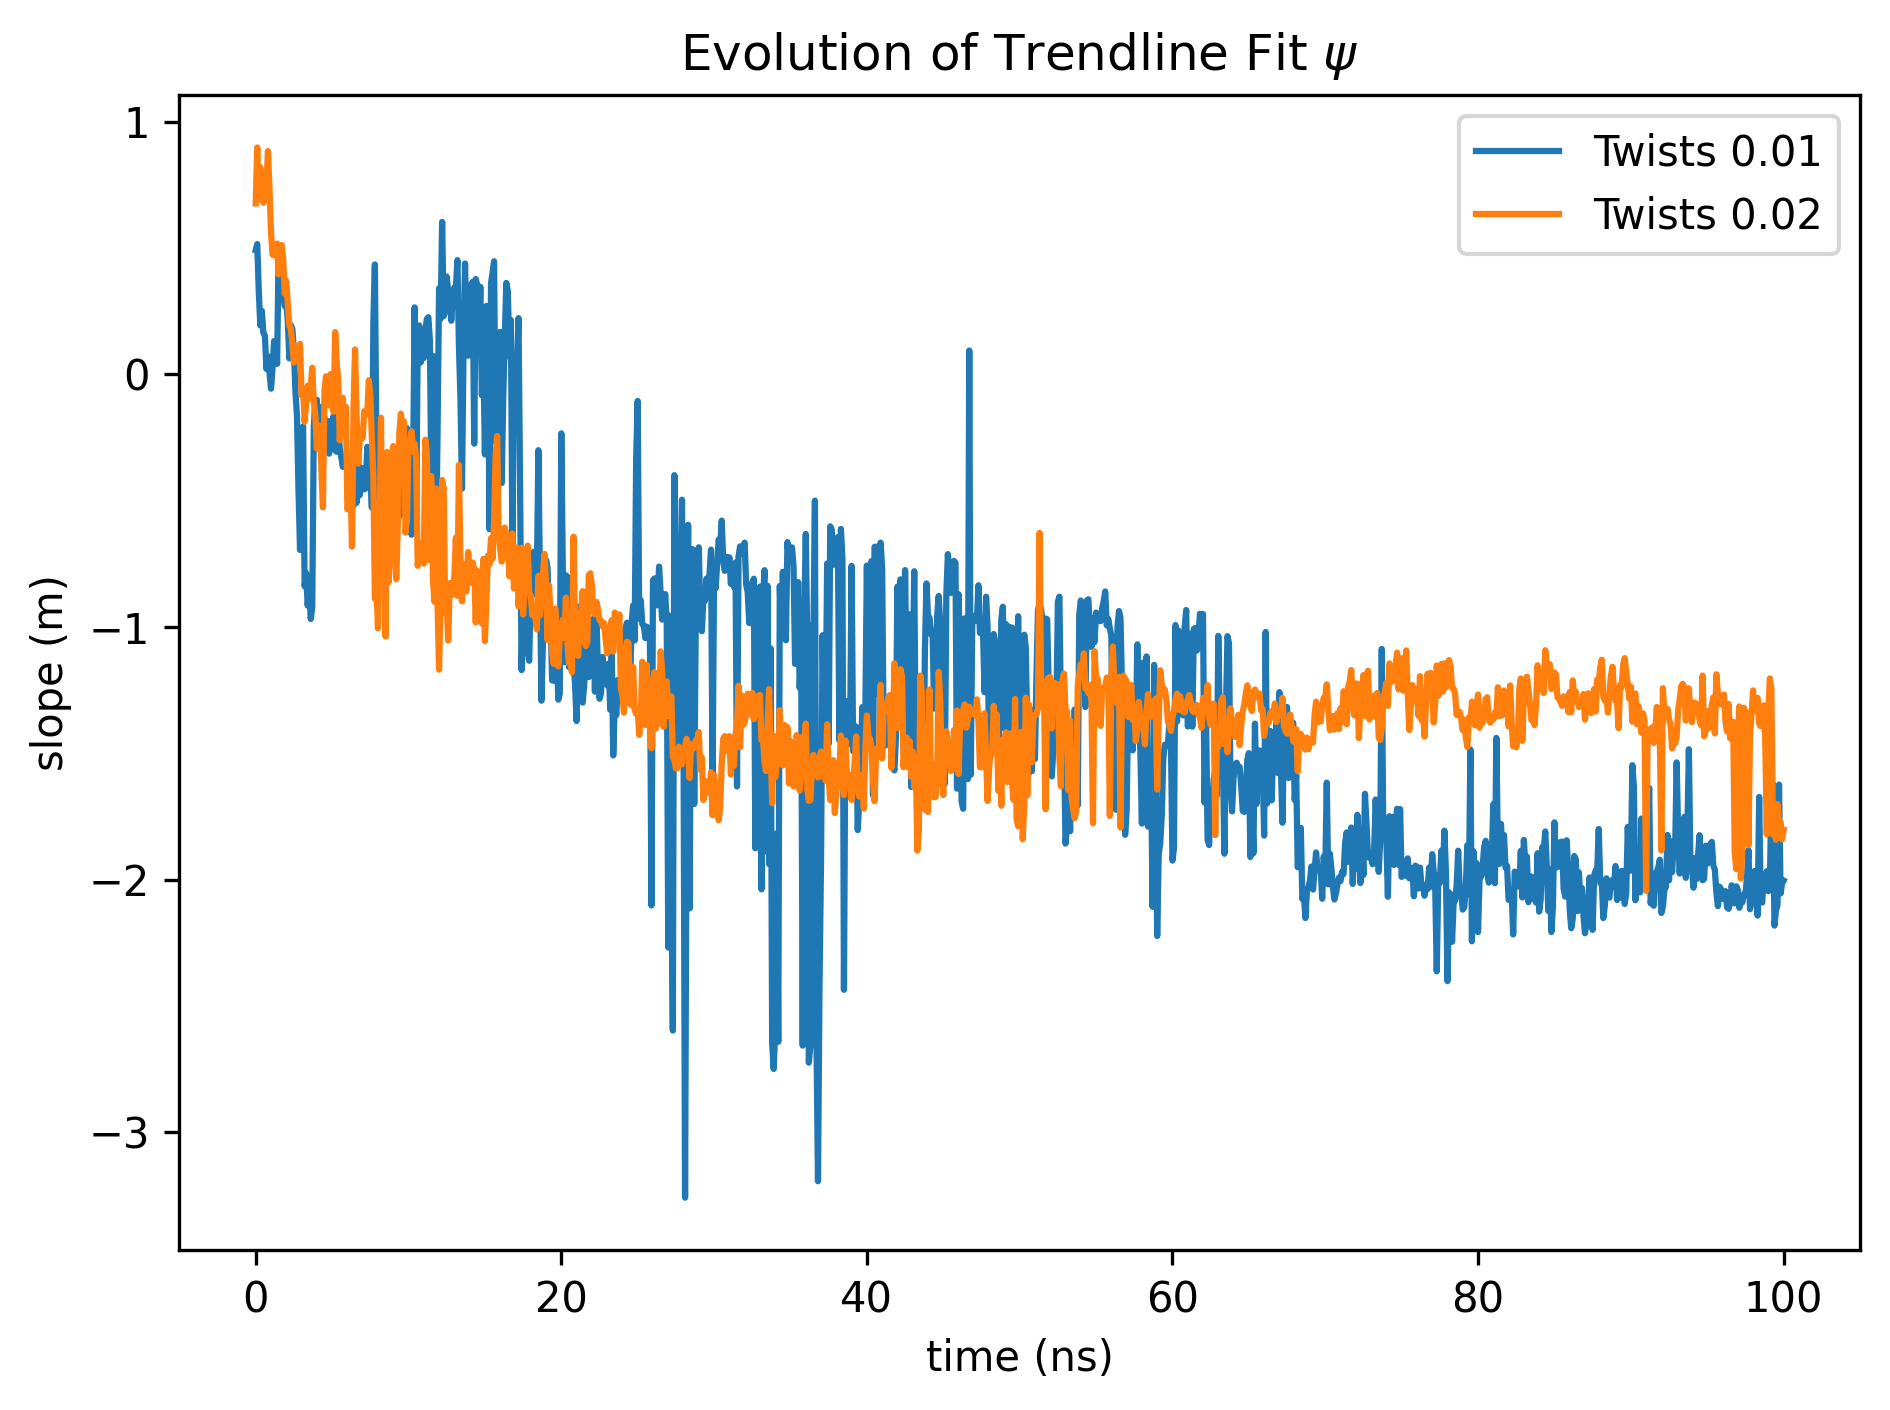

In [5]:
plt.figure(dpi=300)

for p in range(len(twists)):
    slope_p = slope[p]
    plt.plot(time, slope_p, label=f"Twists {twists[p]}")

plt.xlabel("time (ns)")
plt.ylabel("slope (m)")
plt.title(r"Evolution of Trendline Fit $\psi$")
plt.legend()

plt.tight_layout()
plt.show()